# <span style="font-size:16pt; font-weight:bold;">Notebook 20: Comprehensive Dataset and Target EDA</span>

**Purpose:** Full exploratory analysis of the aligned dataset. Covers dataset statistics, target analysis,
artist-aware split verification, genre/year coverage, and advanced statistical tests.


## <span style="font-size:14pt; font-weight:bold;">1. Setup and Imports</span>


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; from scipy import stats; import warnings; warnings.filterwarnings('ignore')
REPO = Path.home() / 'projects' / 'music-prediction'
IMGS = REPO / 'results/figures/thesis'; ANALYSIS = REPO / 'results/analysis'
IMGS.mkdir(parents=True, exist_ok=True); ANALYSIS.mkdir(parents=True, exist_ok=True)
TARGETS = ['Valence', 'Energy', 'Danceability', 'Popularity']
TC = {'Valence':'#4C72B0','Energy':'#DD8452','Danceability':'#55A868','Popularity':'#C44E52'}
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight',
    'font.size':12,'axes.labelsize':14,'axes.titlesize':14})
print('Setup complete.')


Setup complete.


## <span style="font-size:14pt; font-weight:bold;">2. Data Loading</span>


In [2]:
DATA = REPO / 'data/processed'; FEAT = REPO / 'ml/features'
train_df = pd.read_csv(DATA / 'train.csv')
val_df = pd.read_csv(DATA / 'val.csv'); test_df = pd.read_csv(DATA / 'test.csv')

TARGET_KEYS = ['valence', 'energy', 'danceability', 'popularity']
def load_y(split):
    return np.column_stack([np.load(FEAT / f'y_{split}_{t}.npy') for t in TARGET_KEYS])

y_train = load_y('train'); y_val = load_y('val'); y_test = load_y('test')
print(f'Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}')
print(f'y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}')
print(f'Total: {train_df.shape[0]+val_df.shape[0]+test_df.shape[0]:,} songs')
assert train_df.shape[0]==y_train.shape[0] and val_df.shape[0]==y_val.shape[0] and test_df.shape[0]==y_test.shape[0]
print('Shape assertions passed.')

Train: (344428, 24), Val: (72631, 24), Test: (74573, 24)
y_train: (344428, 4), y_val: (72631, 4), y_test: (74573, 4)
Total: 491,632 songs
Shape assertions passed.


## <span style="font-size:14pt; font-weight:bold;">3. Dataset Overview</span>

### 3.1 Split Sizes and Artist Check


     Split  Count       Pct
     Train 344428 70.058092
Validation  72631 14.773448
      Test  74573 15.168459


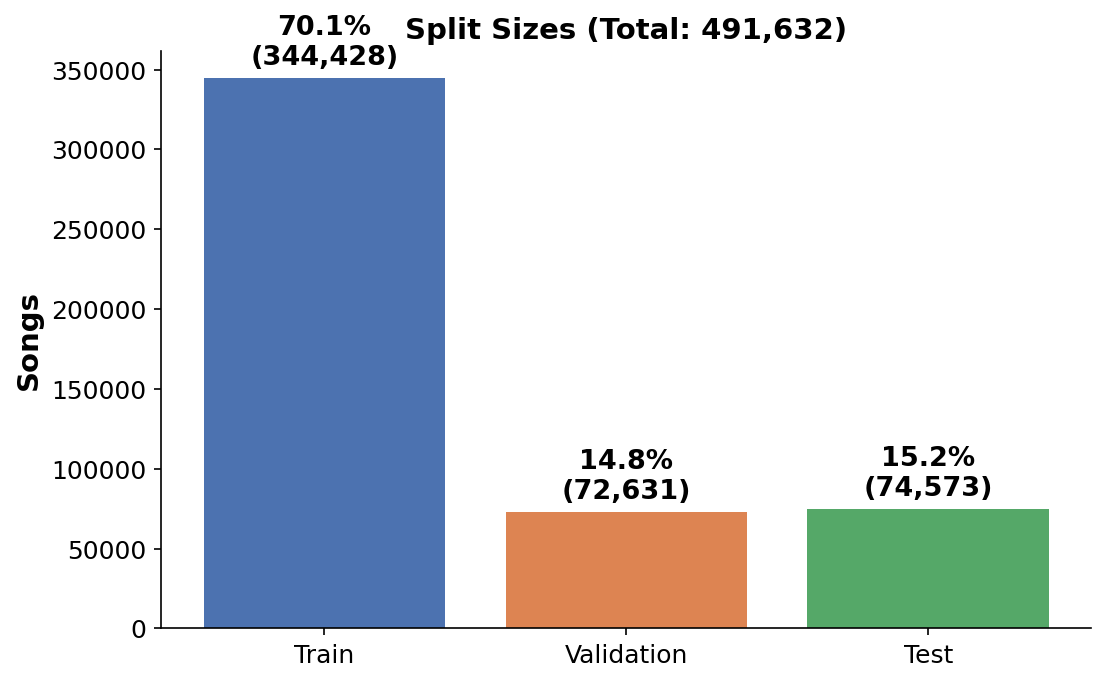

In [3]:
sc = {'Train':len(train_df),'Validation':len(val_df),'Test':len(test_df)}
sdf = pd.DataFrame(list(sc.items()), columns=['Split','Count'])
sdf['Pct'] = sdf['Count']/sdf['Count'].sum()*100
print(sdf.to_string(index=False))
fig,ax = plt.subplots(figsize=(8,5))
bars = ax.bar(sdf['Split'],sdf['Count'],color=['#4C72B0','#DD8452','#55A868'])
for b,p in zip(bars,sdf['Pct']):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+5000,
        f'{p:.1f}%\n({int(b.get_height()):,})',ha='center',va='bottom',fontsize=13,fontweight='bold')
ax.set_ylabel('Songs',fontsize=14,fontweight='bold')
ax.set_title(f'Split Sizes (Total: {sum(sc.values()):,})',fontsize=14,fontweight='bold')
sns.despine(); fig.savefig(IMGS/'20_split_sizes.png'); plt.show()


In [4]:
id_col = 'artists'
for name,df in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    print(f'{name}: {df[id_col].nunique():,} unique artist entries')
ta = set(train_df[id_col]); va = set(val_df[id_col]); tea = set(test_df[id_col])
print(f'Overlapping: T-V={len(ta&va)}, T-Te={len(ta&tea)}, V-Te={len(va&tea)}')
if len(ta&va)+len(ta&tea)+len(va&tea)==0: print('>> PASS: No artist leakage')
else: print('>> FAIL: Leakage detected!')

Train: 59,780 unique artist entries
Val: 13,385 unique artist entries
Test: 12,714 unique artist entries
Overlapping: T-V=0, T-Te=0, V-Te=0
>> PASS: No artist leakage


### 3.2 Feature Composition


Total features: 4254
Small modalities (<100 features):
- Audio features: 23 features
- Text Stats: 5 features
- Sentiment: 2 features

Large modalities (>=100 features):
- MPNet: 768 features
- VGGish: 128 features
- MERT: 768 features
- PANNs: 2048 features
- Mel Stats: 512 features
- Other (Audio features, Text Stats, Sentiment): 30 features


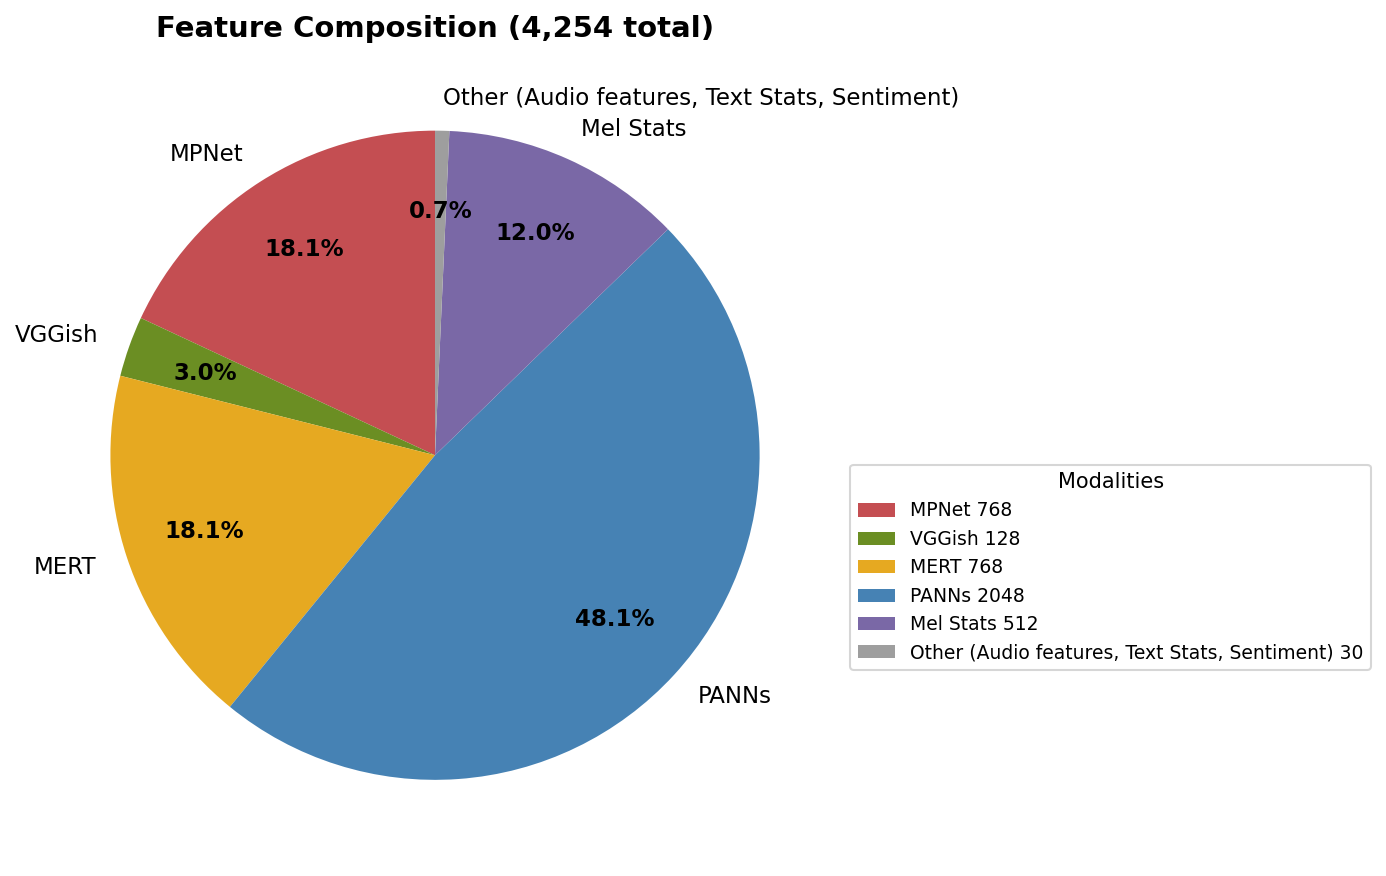

In [5]:
MODS = [('Audio features',23),('Text Stats',5),('Sentiment',2),('MPNet',768),
        ('VGGish',128),('MERT',768),('PANNs',2048),('Mel Stats',512)]
total = sum(d for _,d in MODS); print(f'Total features: {total}'); assert total==4254

small = [m for m in MODS if m[1]<100]
print('Small modalities (<100 features):')
for name, count in small:
    print(f'- {name}: {count} features')
large = [m for m in MODS if m[1]>=100]
if small:
    other_label = f"Other ({', '.join(name for name, _ in small)})"
    other_count = total - sum(d for _, d in large)
    large.append((other_label, other_count))

print('\nLarge modalities (>=100 features):')
for name, count in large:
    print(f'- {name}: {count} features')

pie_labels = [n for n, _ in large]
pie_values = [d for _, d in large]
pie_colors = ['#C44E52', '#6B8E23', '#E6A921', '#4682B4', '#7A68A6', '#9E9E9E']  # Other = gray

fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax.pie(
    pie_values,
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=pie_colors[:len(pie_values)],
    textprops={'fontsize': 11},
    pctdistance=0.75
)

for t in autotexts:
    t.set_fontweight('bold')


ax.legend(
    wedges,
    [format(f'{n} {d}') for n, d in large],
    title='Modalities',
    loc='upper left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9,
    title_fontsize=10
)

ax.set_title('Feature Composition (4,254 total)', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(IMGS / '20_feature_composition.png')
plt.show()

## <span style="font-size:14pt; font-weight:bold;">4. Target Variable Analysis</span>


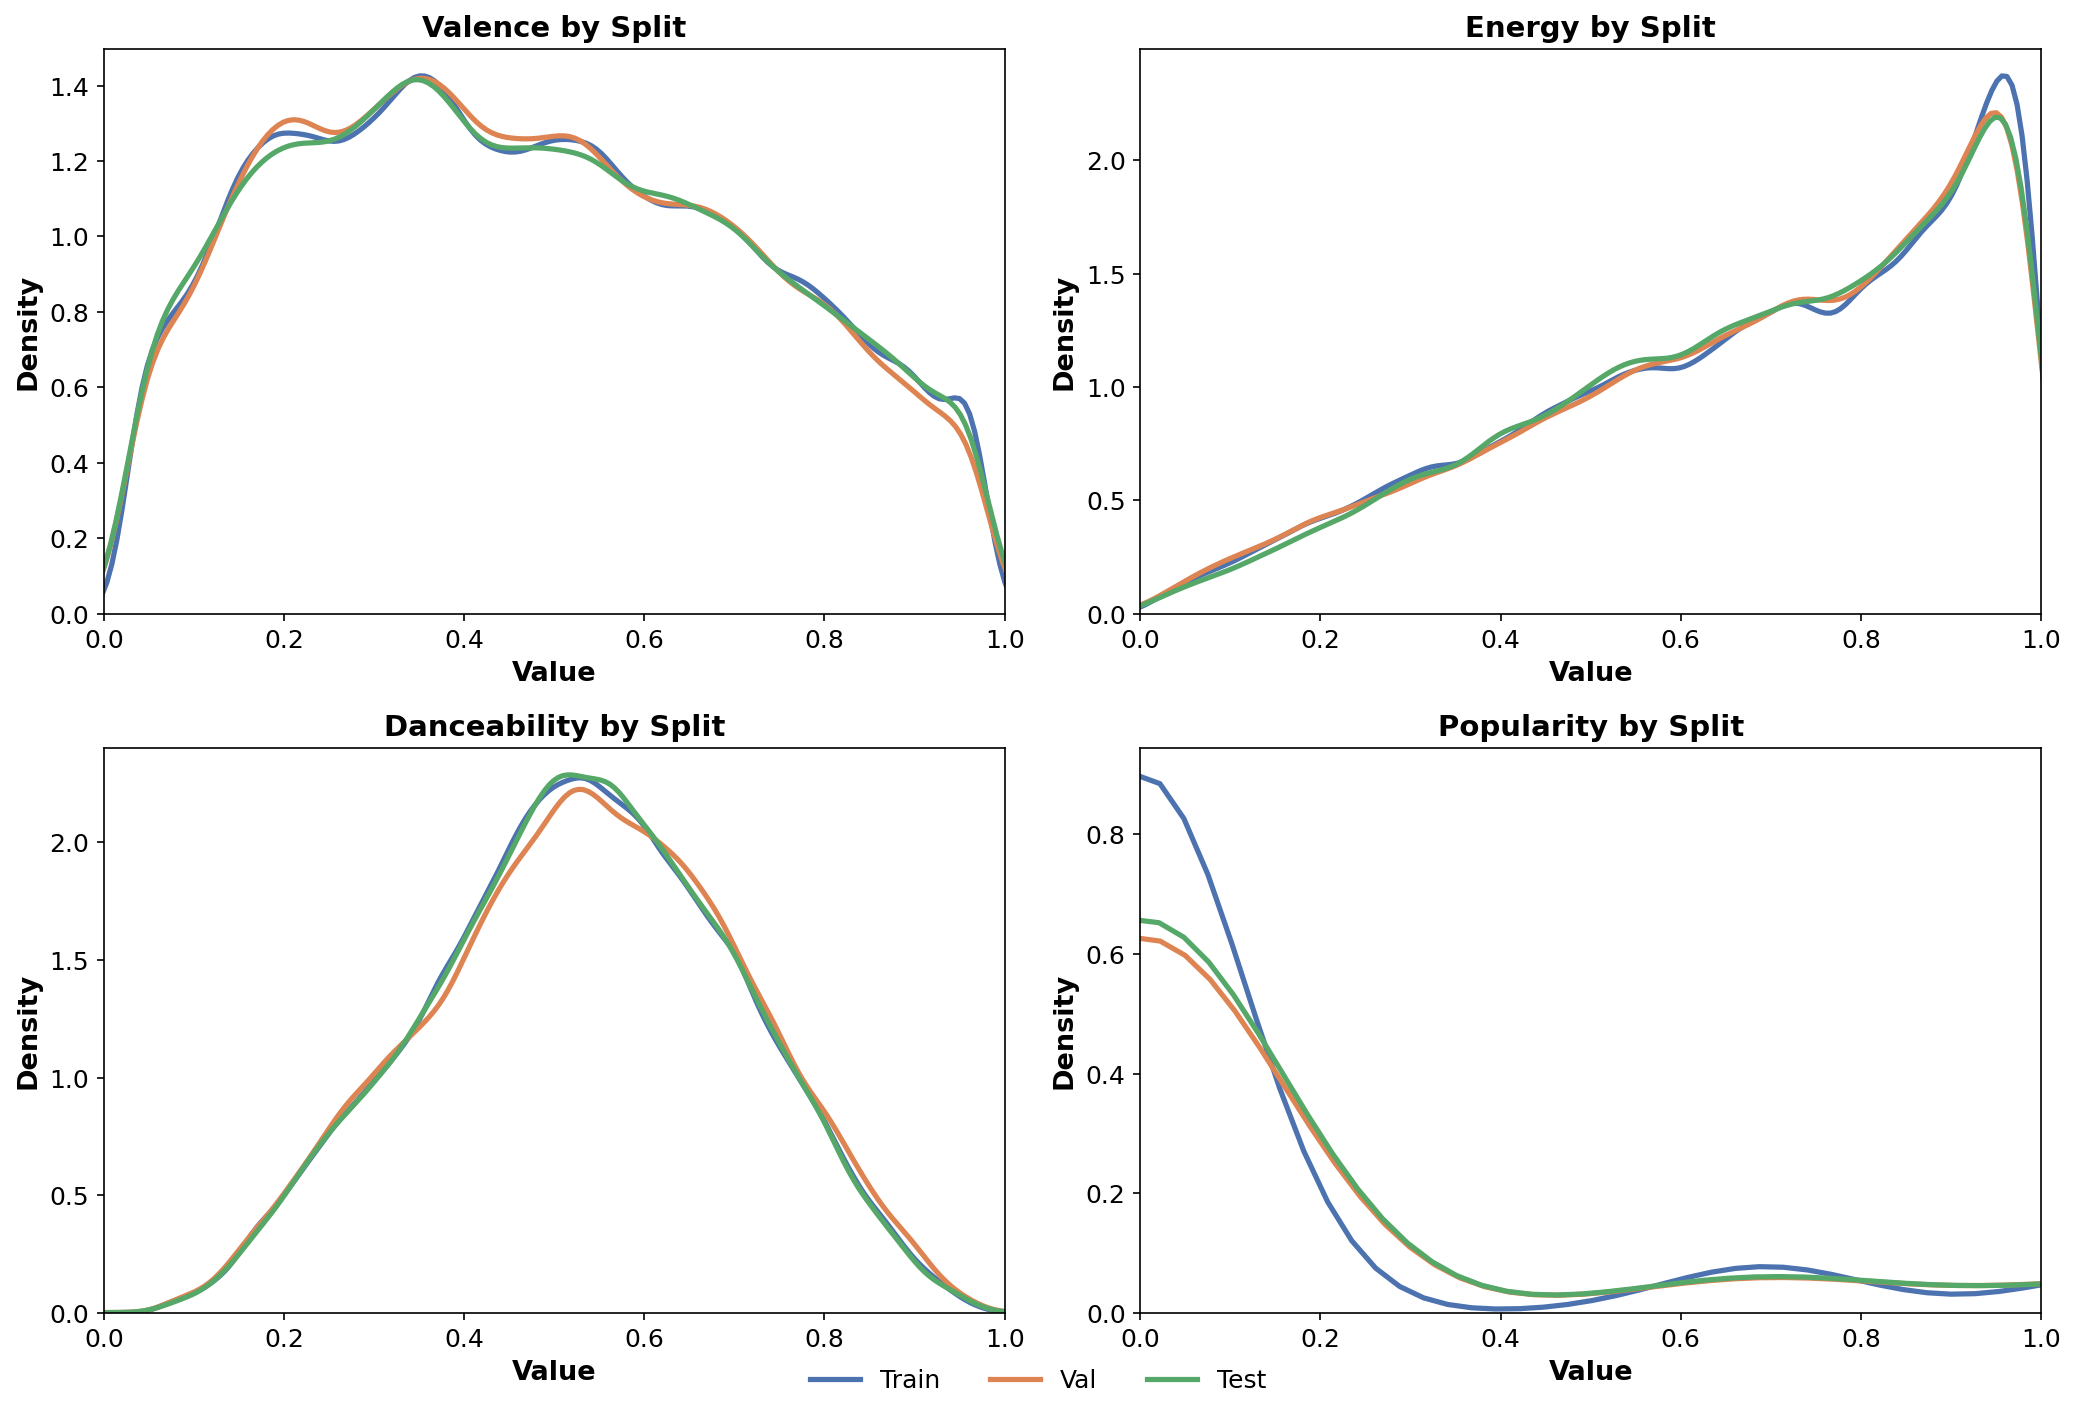

In [6]:
ys = {'Train': y_train, 'Val': y_val, 'Test': y_test}
split_colors = {'Train': '#4C72B0', 'Val': '#DD8452', 'Test': '#55A868'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, t in enumerate(TARGETS):
    ax = axes[idx // 2, idx % 2]
    for sn, yd in ys.items():
        sns.kdeplot(
            yd[:, idx],
            ax=ax,
            color=split_colors[sn],
            linewidth=2.5,
            label=sn if idx == 0 else None
        )
    ax.set_title(f'{t} by Split', fontsize=14, fontweight='bold')
    ax.set_xlabel('Value', fontsize=13, fontweight='bold')
    ax.set_ylabel('Density', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ['Train', 'Val', 'Test'], loc='lower center', ncol=3, frameon=False, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(IMGS / '20_target_distributions.png')
plt.show()


In [7]:
rows=[]
for sn,yd in ys.items():
    for idx,t in enumerate(TARGETS):
        col=yd[:,idx]; rows.append({'Split':sn,'Target':t,'Mean':f'{col.mean():.4f}',
            'Std':f'{col.std():.4f}','Skew':f'{stats.skew(col):.4f}','Kurt':f'{stats.kurtosis(col):.4f}'})
print(pd.DataFrame(rows).to_string(index=False))


Split       Target   Mean    Std    Skew    Kurt
Train      Valence 0.4683 0.2488  0.1874 -0.9737
Train       Energy 0.6719 0.2446 -0.5912 -0.6261
Train Danceability 0.5299 0.1714 -0.0819 -0.4742
Train   Popularity 2.1921 1.4978 -0.4787 -1.3635
  Val      Valence 0.4643 0.2464  0.1969 -0.9536
  Val       Energy 0.6717 0.2440 -0.6128 -0.5797
  Val Danceability 0.5345 0.1748 -0.0977 -0.5163
  Val   Popularity 2.2571 1.4919 -0.5458 -1.2897
 Test      Valence 0.4673 0.2497  0.1867 -0.9737
 Test       Energy 0.6743 0.2394 -0.5890 -0.5853
 Test Danceability 0.5302 0.1704 -0.0878 -0.4691
 Test   Popularity 2.2070 1.4931 -0.5066 -1.3415


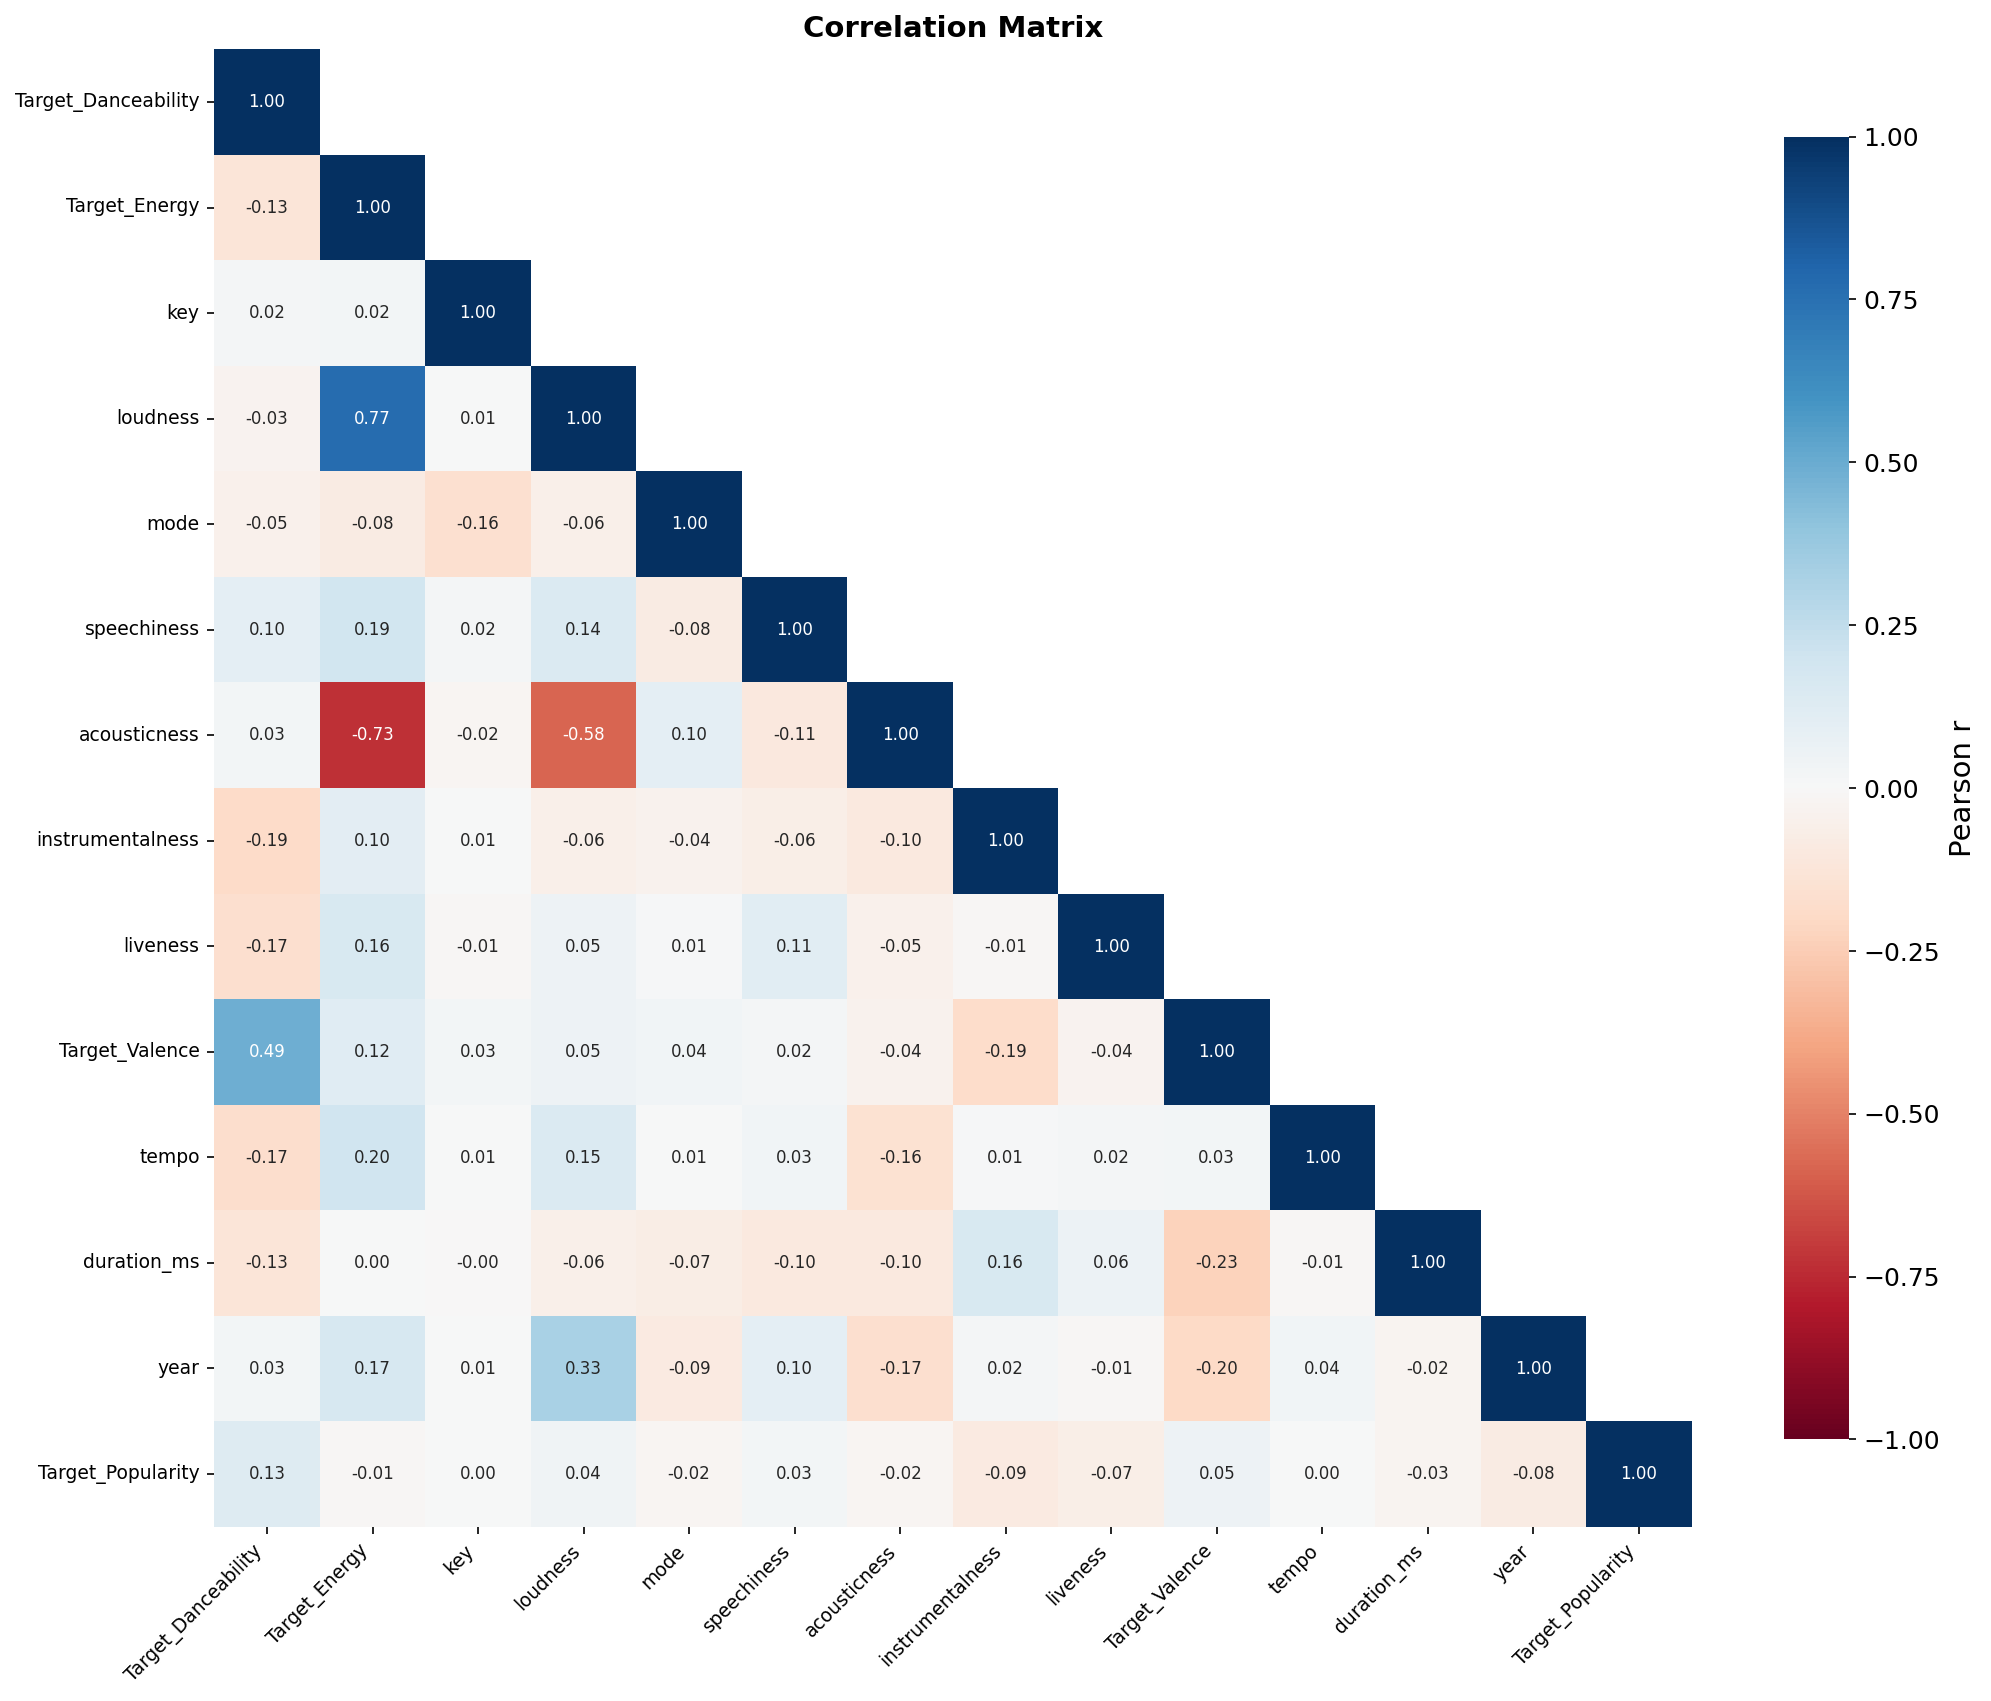

Target-to-Feature Correlations:
                       key  loudness   mode  speechiness  acousticness  instrumentalness  liveness  tempo  duration_ms   year
Target_Valence       0.029     0.053  0.038        0.019        -0.041            -0.187    -0.037  0.029       -0.228 -0.197
Target_Energy        0.024     0.767 -0.084        0.190        -0.731             0.103     0.159  0.197        0.001  0.166
Target_Danceability  0.023    -0.033 -0.051        0.100         0.028            -0.188    -0.166 -0.174       -0.126  0.026
Target_Popularity    0.000     0.040 -0.019        0.028        -0.021            -0.092    -0.070  0.002       -0.028 -0.078


In [8]:
# Combine targets with base audio features from CSV
FEAT_COLS = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
             'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
             'duration_ms', 'year', 'popularity']
audio_df = test_df[FEAT_COLS].copy()
# Rename targets to indicate they're our targets
audio_df = audio_df.rename(columns={
    'valence': 'Target_Valence', 'energy': 'Target_Energy',
    'danceability': 'Target_Danceability', 'popularity': 'Target_Popularity'})

corr = audio_df.corr()
fig,ax = plt.subplots(figsize=(14,12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu',
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Correlation Matrix',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
fig.tight_layout(); fig.savefig(IMGS/'20_full_correlation.png'); plt.show()

# Also highlight target-to-feature correlations
print('Target-to-Feature Correlations:')
print('='*60)
target_cols = ['Target_Valence', 'Target_Energy', 'Target_Danceability', 'Target_Popularity']
feat_cols = [c for c in FEAT_COLS if c not in ['valence','energy','danceability','popularity']]
# But the feat names changed since we renamed... let me just show it differently
print(corr.loc[target_cols].drop(columns=target_cols).round(3).to_string())

## <span style="font-size:14pt; font-weight:bold;">5. Genre Analysis</span>


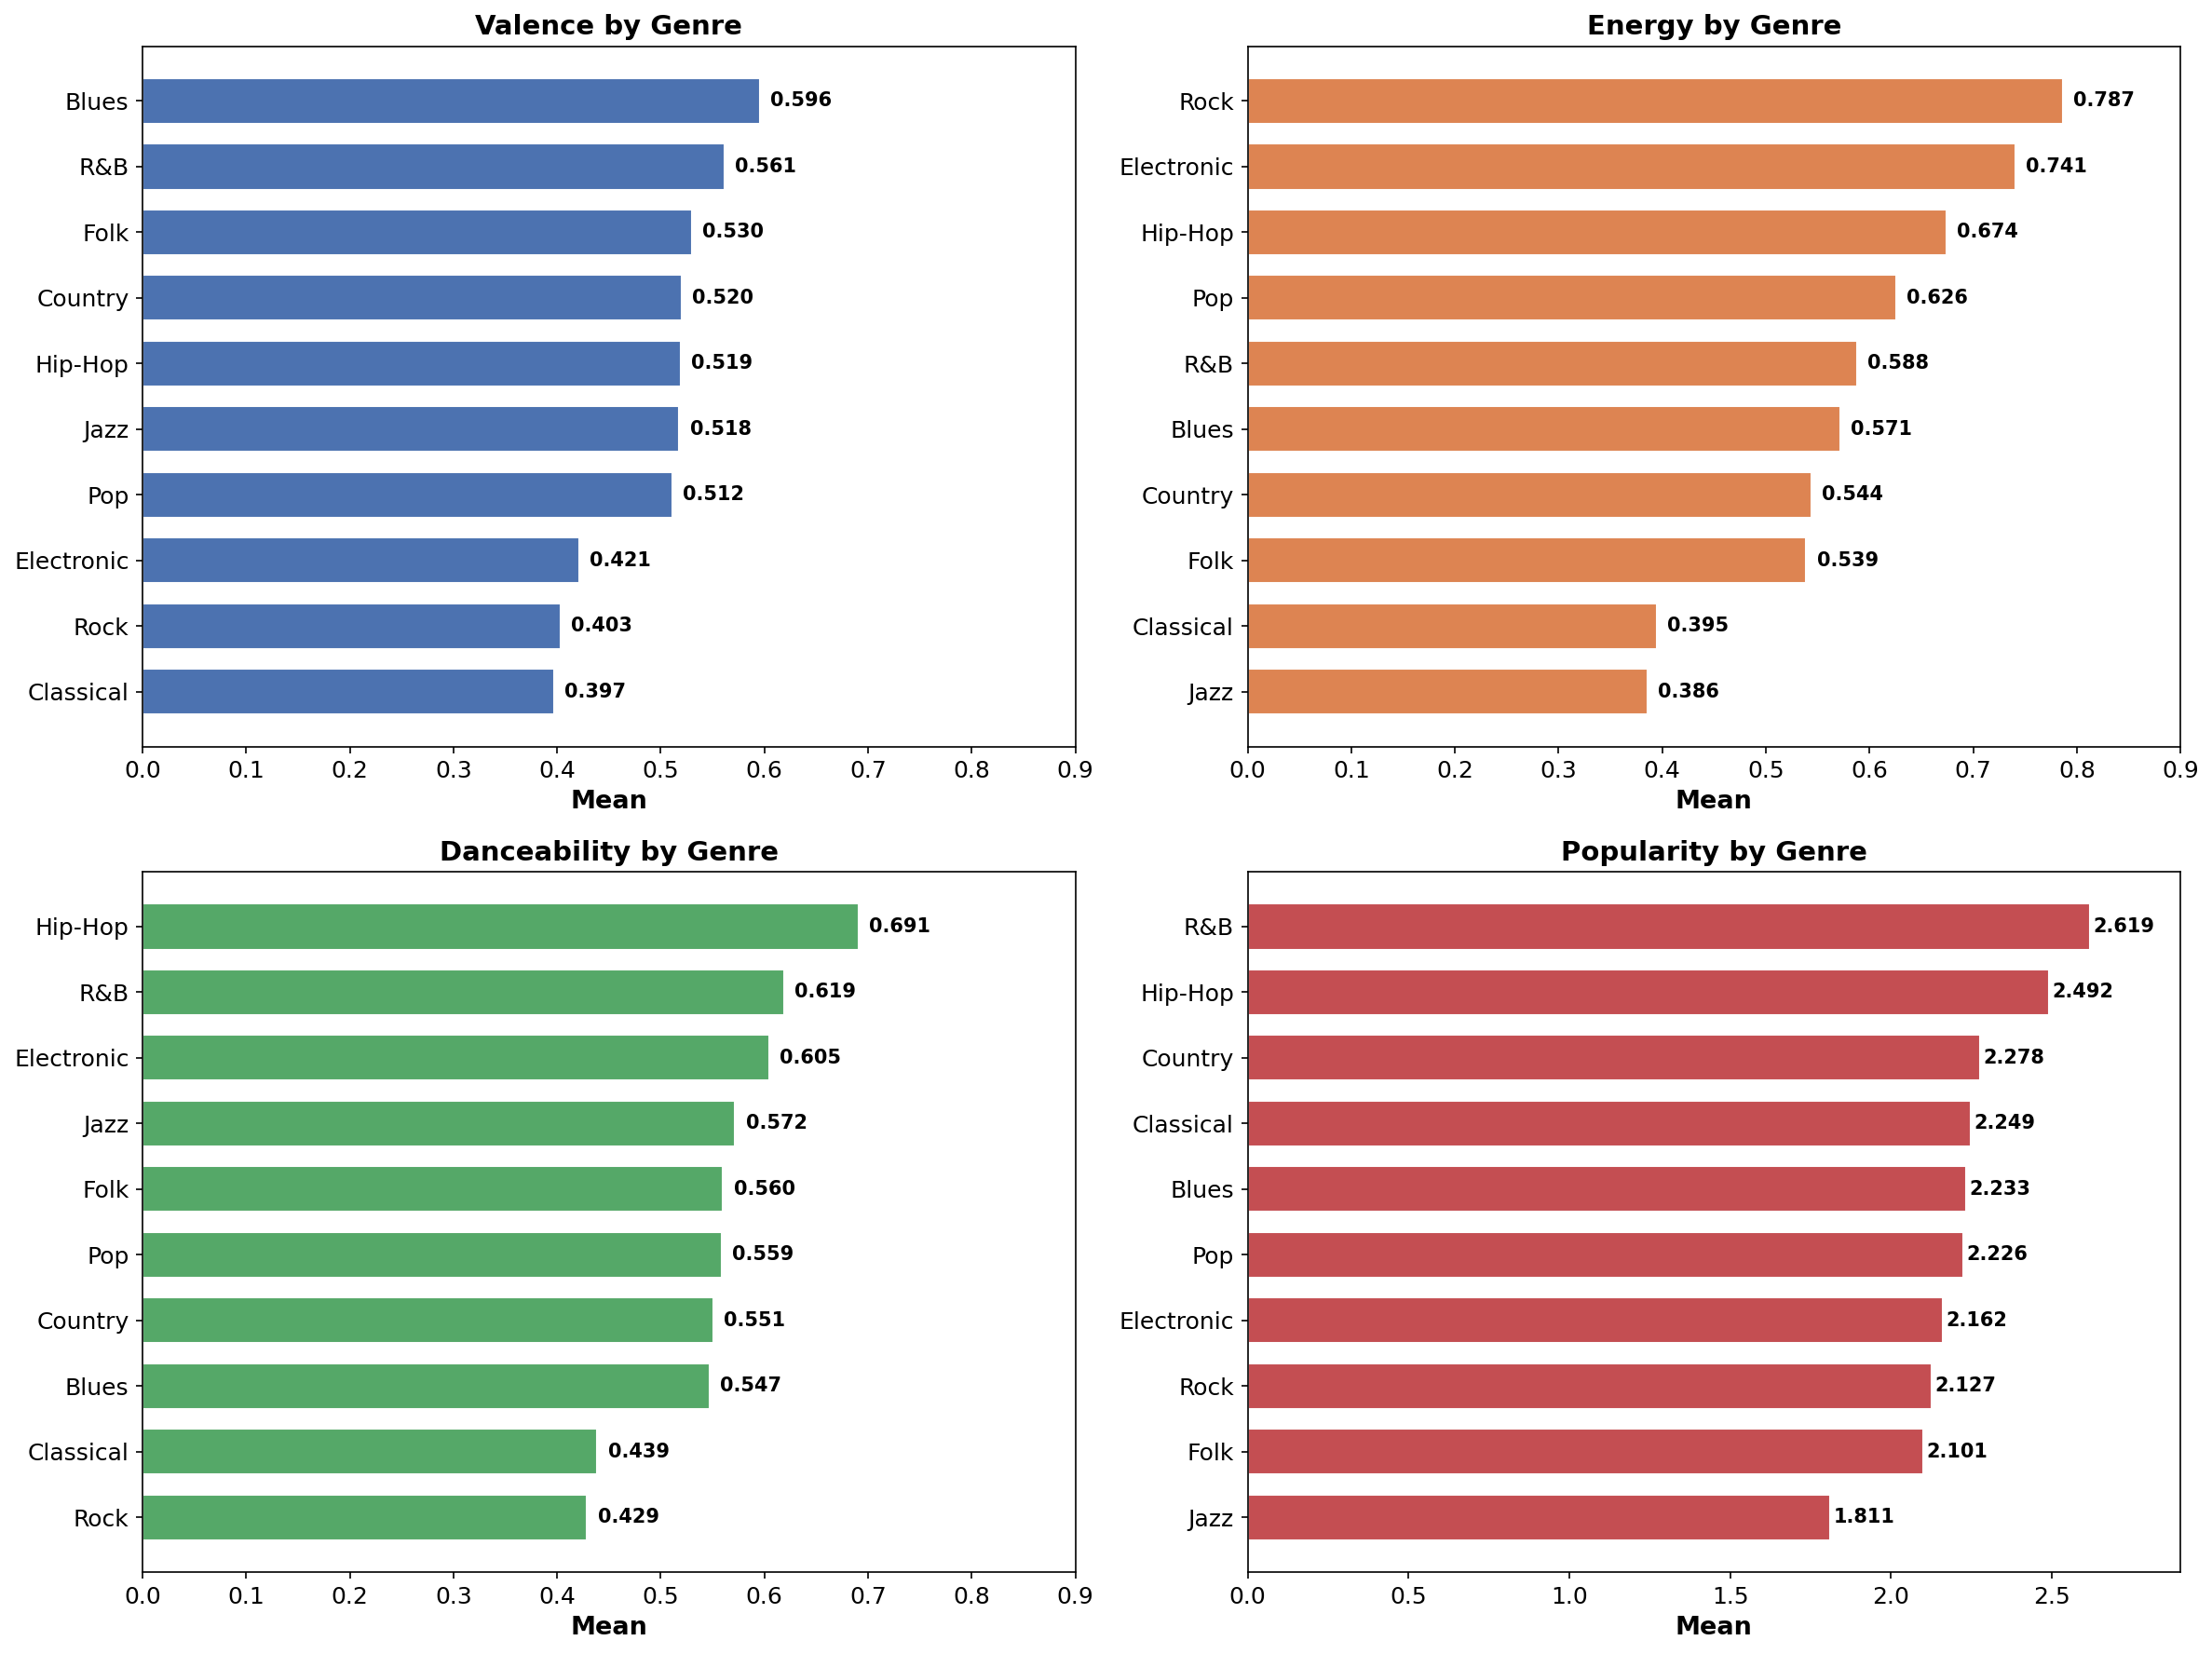

In [9]:
if 'genre' in test_df.columns:
    rows=[]
    for idx,t in enumerate(TARGETS):
        for g in test_df['genre'].unique():
            m=test_df['genre']==g; rows.append({'Genre':g,'Target':t,'Mean':y_test[m,idx].mean(),'Count':m.sum()})
    gm=pd.DataFrame(rows); tg=test_df['genre'].value_counts().head(10).index; gt=gm[gm['Genre'].isin(tg)]
    fig,axes=plt.subplots(2,2,figsize=(16,12))
    for idx,t in enumerate(TARGETS):
        ax=axes[idx//2,idx%2]; sub=gt[gt['Target']==t].sort_values('Mean',ascending=False)
        bars=ax.barh(sub['Genre'],sub['Mean'],color=TC[t],edgecolor='white',height=0.7)
        for b,v in zip(bars,sub['Mean']): ax.text(b.get_width()+0.01,b.get_y()+b.get_height()/2,f'{v:.3f}',va='center',fontsize=10,fontweight='bold')
        ax.set_title(f'{t} by Genre',fontsize=14,fontweight='bold'); ax.set_xlabel('Mean',fontsize=13,fontweight='bold')
        if t=='Popularity': ax.set_xlim(0,2.9)
        else: ax.set_xlim(0,0.9)
        ax.invert_yaxis()
    plt.tight_layout(); fig.savefig(IMGS/'20_genre_target_means.png'); plt.show()
else: print('genre column not found.')


In [10]:
if 'genre' in test_df.columns:
    print('ANOVA: Genre effect on targets'); print('-'*50)
    for idx,t in enumerate(TARGETS):
        groups=[y_test[test_df['genre']==g,idx] for g in test_df['genre'].unique()]
        f,p=stats.f_oneway(*groups); print(f'  {t}: F={f:.2f}, p={p:.2e}', 'SIGNIFICANT' if p<0.05 else 'NS')


ANOVA: Genre effect on targets
--------------------------------------------------
  Valence: F=548.15, p=0.00e+00 SIGNIFICANT
  Energy: F=2297.81, p=0.00e+00 SIGNIFICANT
  Danceability: F=2765.22, p=0.00e+00 SIGNIFICANT
  Popularity: F=90.16, p=0.00e+00 SIGNIFICANT


## <span style="font-size:14pt; font-weight:bold;">6. Advanced Statistical Tests</span>


Normality Test (D'Agostino-Pearson) -- Test Set
--------------------------------------------------
  Valence: stat=15325.82, p=0.00e+00
  Energy: stat=5964.79, p=0.00e+00
  Danceability: stat=1296.50, p=0.00e+00
  Popularity: stat=2152758.25, p=0.00e+00


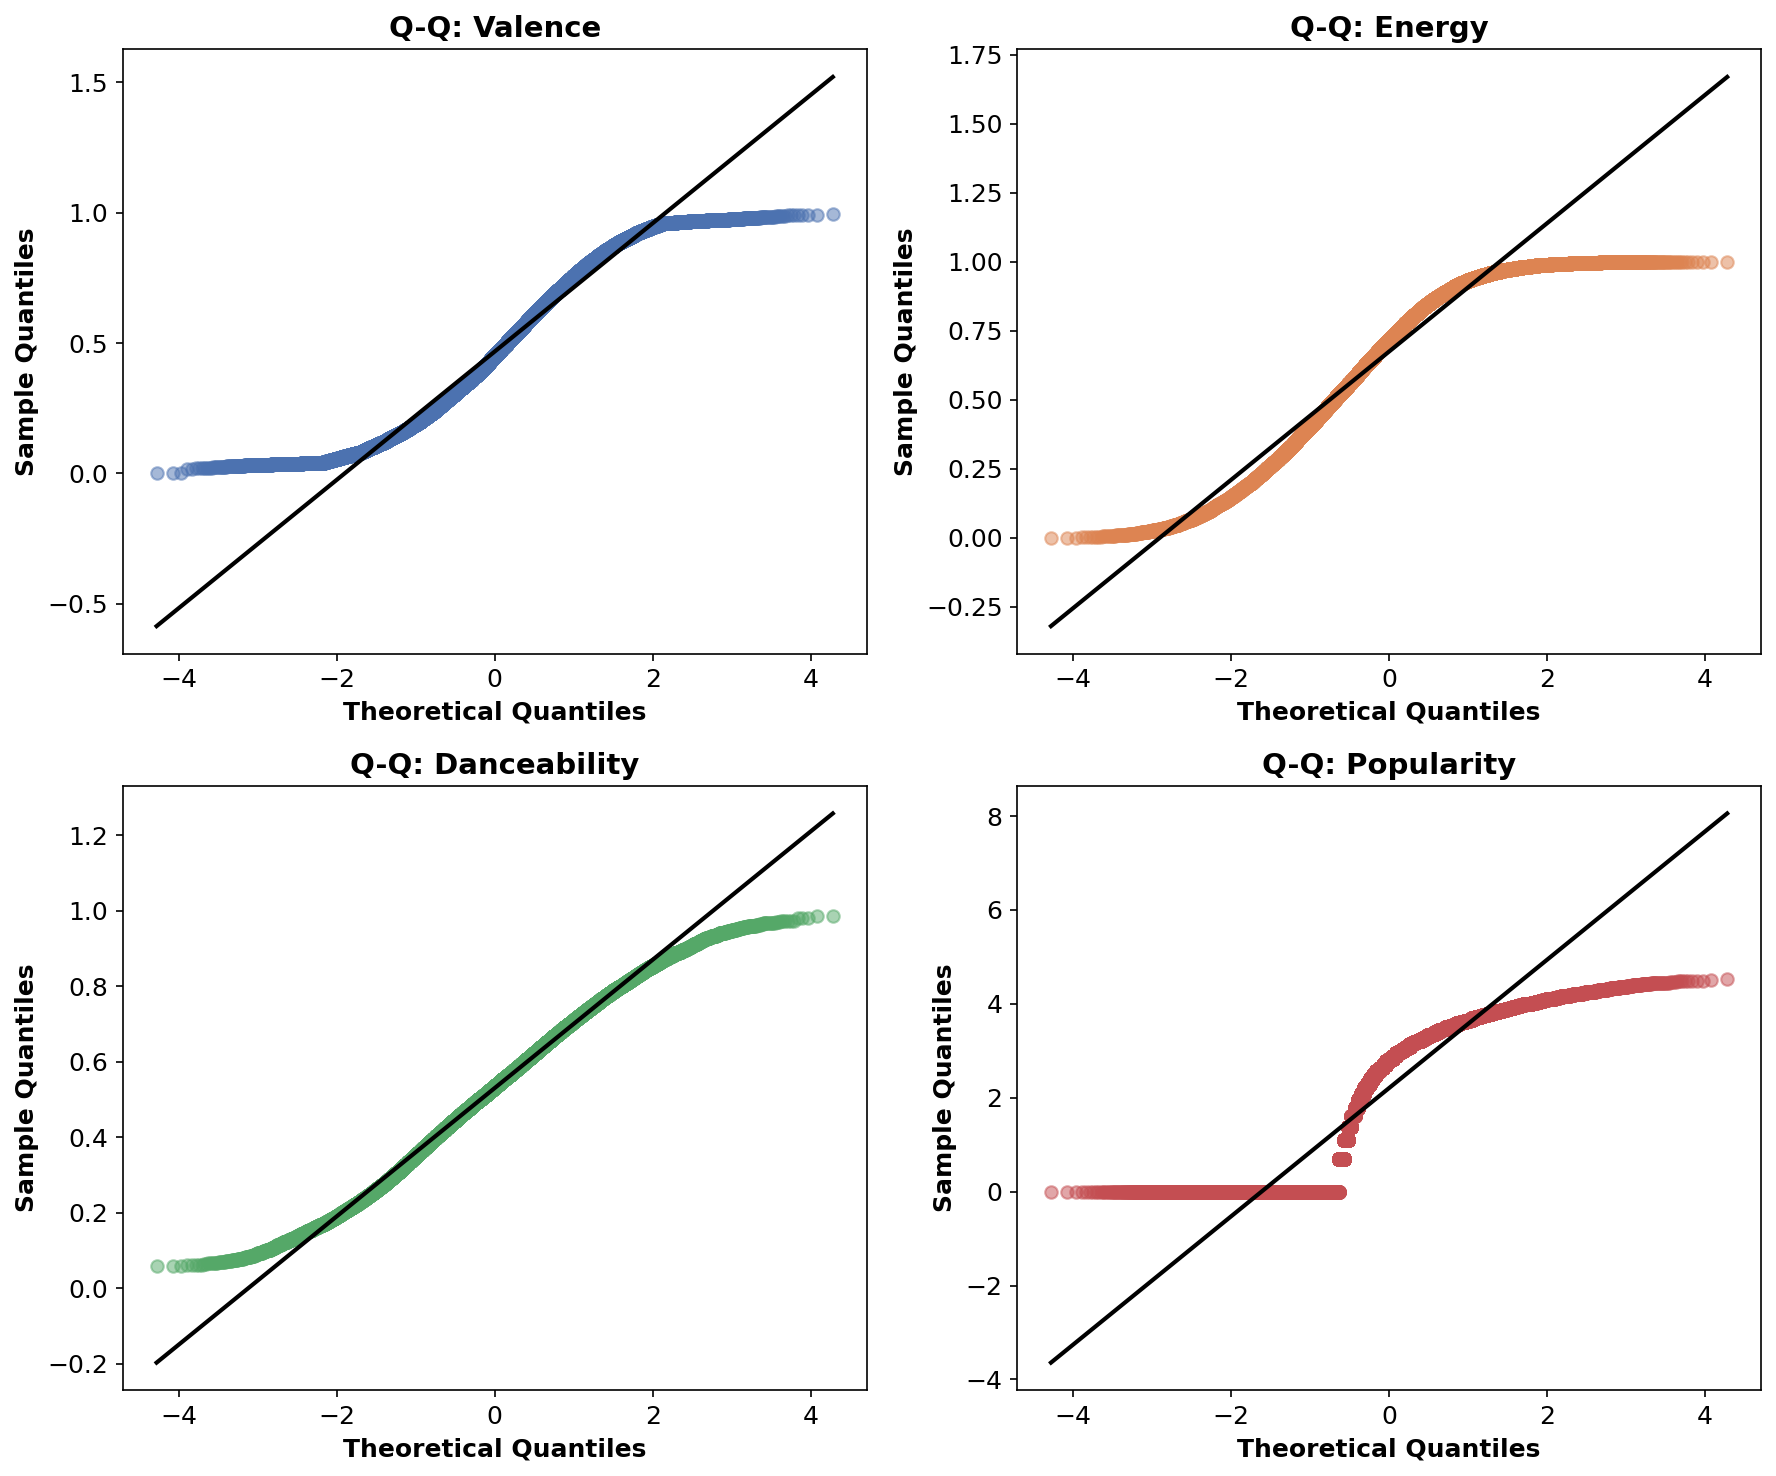

In [11]:
print("Normality Test (D'Agostino-Pearson) -- Test Set"); print('-'*50)
for idx,t in enumerate(TARGETS):
    s,p=stats.normaltest(y_test[:,idx]); print(f'  {t}: stat={s:.2f}, p={p:.2e}')
fig,axes=plt.subplots(2,2,figsize=(12,10))
for idx,t in enumerate(TARGETS):
    ax=axes[idx//2,idx%2]; stats.probplot(y_test[:,idx],dist='norm',plot=ax)
    ax.get_lines()[0].set_markerfacecolor(TC[t]); ax.get_lines()[0].set_markeredgecolor(TC[t]); ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[1].set_color('black'); ax.get_lines()[1].set_linewidth(2)
    ax.set_title(f'Q-Q: {t}',fontsize=14,fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles',fontsize=12,fontweight='bold'); ax.set_ylabel('Sample Quantiles',fontsize=12,fontweight='bold')
plt.tight_layout(); fig.savefig(IMGS/'20_qq_plots.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">7. Key Findings</span>


In [12]:
print('NOTEBOOK 20: KEY FINDINGS')
print(f'1. Dataset: {train_df.shape[0]+val_df.shape[0]+test_df.shape[0]:,} songs ({len(train_df):,}/{len(val_df):,}/{len(test_df):,})')
print(f'2. Features: {total}D across {len(MODS)} modalities')
max_r = np.max(np.abs(corr.values[np.triu_indices_from(corr.values, k=1)]))
print(f'3. Target correlations: max |r|={max_r:.3f}')
print(f'4. Genre significantly affects all targets (ANOVA p<0.001)')
pd.DataFrame([{'samples':int(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]),'features':total}]).to_csv(ANALYSIS/'20_dataset_summary.csv',index=False)
print('\nNotebook 20 complete.')

NOTEBOOK 20: KEY FINDINGS
1. Dataset: 491,632 songs (344,428/72,631/74,573)
2. Features: 4254D across 8 modalities
3. Target correlations: max |r|=0.767
4. Genre significantly affects all targets (ANOVA p<0.001)

Notebook 20 complete.
